# Agent模型初始化方法
##  1.Agent模型的传入方式 
### 1.1字符串 

In [4]:
from dotenv import load_dotenv
from langchain.agents import create_agent

load_dotenv(override=True)

agent = create_agent(
    model ="Ark:glm-5-3-flash-260828"
)
print(type(agent))

ValueError: Unable to infer model provider for model='Ark:glm-5-3-flash-260828'. Please specify 'model_provider' directly.

Supported providers: anthropic, anthropic_bedrock, azure_ai, azure_openai, bedrock, bedrock_converse, cohere, deepseek, fireworks, google_anthropic_vertex, google_genai, google_vertexai, groq, huggingface, ibm, mistralai, nvidia, ollama, openai, openrouter, perplexity, together, upstage, xai

For help with specific providers, see: https://docs.langchain.com/oss/python/integrations/providers

Ok阿，也是出师未捷身先死，使用的火山引擎的免费额度不支持这玩意
https://reference.langchain.org.cn/python/langchain/models/#langchain.chat_models.init_chat_model(model_provider)
https://docs.langchain.com/oss/deepagents/code/providers#provider-reference

我们就直接换成第二种方式吧

补充：好像错怪他了，配置错误了，后面换一种导入方式试试看，不适用chatOpenAi 换成init_chat_model方法试试看

<class 'langgraph.graph.state.CompiledStateGraph'>


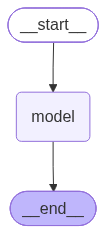

In [ ]:
import os
from dotenv import load_dotenv

from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

load_dotenv(override=True)
ARK_API_KEY = os.getenv("ARK_API_KEY")
ARK_MODEL_NAME = os.getenv("ARK_MODEL_NAME")
ARK_BASE_URL = os.getenv("ARK_BASE_URL")
model = ChatOpenAI(
    model= ARK_MODEL_NAME,
    api_key= ARK_API_KEY,
    base_url= ARK_BASE_URL
)
agent = create_agent(
    model = model
)
print(type(agent))


from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

## 2、如何调用agent

In [6]:
import os
from dotenv import load_dotenv

from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from rich import print as rprint

load_dotenv(override=True)
ARK_API_KEY = os.getenv("ARK_API_KEY")
ARK_MODEL_NAME = os.getenv("ARK_MODEL_NAME")
ARK_BASE_URL = os.getenv("ARK_BASE_URL")
model = ChatOpenAI(
    model= ARK_MODEL_NAME,
    api_key= ARK_API_KEY,
    base_url= ARK_BASE_URL
)
agent = create_agent(
    model = model
)
#调用
response = agent.invoke({
    "messages":[
        {"role":"user","content":"你好"}
    ]
})

rprint(response)


{
    'messages': [
        HumanMessage(
            content='你好',
            additional_kwargs={},
            response_metadata={},
            id='5e874acd-cd49-4a85-8938-98863330cae7'
        ),
        AIMessage(
            content='你好！很高兴见到你。我是GLM，Z.ai训练的大语言模型。\n\n今天我能为你做些什么？无论是回答问题、
提供信息，还是进行日常交流，我都很乐意帮助你。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 144,
                    'prompt_tokens': 13,
                    'total_tokens': 157,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 103,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '0217900902885777d6713dc852f73f0cf900d2fbe3d44888e1e8c',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a0c9b2-1dab-76b2-8418-83a160a07cf6-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 13,
                'output_tokens': 144,
                'total_tokens': 157,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 103}
            }
        )
    ]
}

## 3、 工具绑定

In [7]:
import os
from dotenv import load_dotenv
from langchain_core.tools import tool

from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from rich import print as rprint

load_dotenv(override=True)
ARK_API_KEY = os.getenv("ARK_API_KEY")
ARK_MODEL_NAME = os.getenv("ARK_MODEL_NAME")
ARK_BASE_URL = os.getenv("ARK_BASE_URL")
model = ChatOpenAI(
    model= ARK_MODEL_NAME,
    api_key= ARK_API_KEY,
    base_url= ARK_BASE_URL
)

#定义工具
@tool(parse_docstring =True)
def get_weather(city:str):
    '''
    查询天气的工具

    Args:
        city: 具体的城市
    '''
    return f"{city}的天气晴朗，温度20摄氏度"

agent = create_agent(
    model = model,
    tools=[get_weather]
)

#调用
response = agent.invoke({
    "messages":[
        {"role":"system","content":"你是一个专业的天气预报员，根据用户的问题回答相应的天气信息，如果问的问题与天气无关，你可以直接拒绝回答"},
        {"role":"user","content":"明天杭州的天气如何"}
    ]
})

rprint(response)


{
    'messages': [
        SystemMessage(
            content='你是一个专业的天气预报员，根据用户的问题回答相应的天气信息，如果问的问题与天气无关，你可以直接
拒绝回答',
            additional_kwargs={},
            response_metadata={},
            id='a040c315-8205-400a-ac33-714ae8352031'
        ),
        HumanMessage(
            content='明天杭州的天气如何',
            additional_kwargs={},
            response_metadata={},
            id='d507b399-a458-4f65-9d3e-2ba319412ae2'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 40,
                    'prompt_tokens': 189,
                    'total_tokens': 229,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 29,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '021790090942153de824baea9702e17bffa39e9c3bdc4f6a0ba4b',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0c9bc-169b-7912-a250-e9fa79eb750c-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '杭州'},
                    'id': 'call_rdjw7gop6dhxe9fdnnpng7f1',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 189,
                'output_tokens': 40,
                'total_tokens': 229,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 29}
            }
        ),
        ToolMessage(
            content='杭州的天气晴朗，温度20摄氏度',
            name='get_weather',
            id='285d6cb7-a6cb-49c1-b431-d821c7af1ca6',
            tool_call_id='call_rdjw7gop6dhxe9fdnnpng7f1'
        ),
        AIMessage(
            content='根据查询结果，杭州明天的天气情况如下：\n\n🌤️ **杭州天气预报**\n- **天气状况**：晴朗 ☀️\n- 
**温度**：20℃\n\n明天杭州天气非常不错，晴空万里，温度适宜，很适合外出活动。建议您可以适当添加一件薄外套，早晚温差可
能较大。祝您有美好的一天！',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 100,
                    'prompt_tokens': 215,
                    'total_tokens': 315,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 26,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '021790090943853de824baea9702e17bffa39e9c3bdc4f6fddb0e',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs':

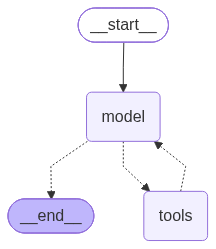

In [8]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

## 调用langchan内置的工具

In [9]:
import os
from dotenv import load_dotenv
from langchain_core.tools import tool

from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from rich import print as rprint

load_dotenv(override=True)
ARK_API_KEY = os.getenv("ARK_API_KEY")
ARK_MODEL_NAME = os.getenv("ARK_MODEL_NAME")
ARK_BASE_URL = os.getenv("ARK_BASE_URL")
model = ChatOpenAI(
    model= ARK_MODEL_NAME,
    api_key= ARK_API_KEY,
    base_url= ARK_BASE_URL
)

#定义工具
@tool(parse_docstring =True)
def get_weather(city:str):
    '''
    查询天气的工具

    Args:
        city: 具体的城市
    '''
    return f"{city}的天气晴朗，温度20摄氏度"

@tool(parse_docstring=True)
def search_movie(keyword: str):
    """
    根据关键词搜索电影

    Args:
        keyword: 搜索关键词，例如 "科幻"、"诺兰"
    """
    fake_db = {
        "科幻": ["星际穿越", "盗梦空间", "降临"],
        "诺兰": ["星际穿越", "盗梦空间", "信条"],
        "宫崎骏": ["千与千寻", "龙猫", "天空之城"],
    }
    results = fake_db.get(keyword, [])
    if results:
        return f"关于「{keyword}」的电影有：{', '.join(results)}"
    return f"没有找到关于「{keyword}」的电影"

agent = create_agent(
    model = model,
    tools=[get_weather,search_movie]
)

#调用
response = agent.invoke({
    "messages":["请依照明天杭州的天气为我推荐一部诺兰的电影"]
})

rprint(response)


{
    'messages': [
        HumanMessage(
            content='请依照明天杭州的天气为我推荐一部诺兰的电影',
            additional_kwargs={},
            response_metadata={},
            id='080bedc1-ab46-4033-a6b0-fc609e7443bd'
        ),
        AIMessage(
            content='我来帮您查询杭州明天的天气，并搜索诺兰的电影。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 99,
                    'prompt_tokens': 230,
                    'total_tokens': 329,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 62,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_tokens': None,
                        'cached_tokens': 0,
                        'image_tokens': None,
                        'text_tokens': None
                    }
                },
                'model_provider': 'openai',
                'model_name': 'glm-5-3-flash-260828',
                'system_fingerprint': None,
                'id': '021790091586615c237340934591b89d6de6b6a9271c1b94c5ccc',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a0c9c5-ec0a-7b33-b97f-1fefb474ca1e-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '杭州'},
                    'id': 'call_swalc8m8b3x2lkf1tgk6pz50',
                    'type': 'tool_call'
                },
                {
                    'name': 'search_movie',
                    'args': {'keyword': '诺兰'},
                    'id': 'call_pk1lnip8vyuqnckp1rs00u1a',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 230,
                'output_tokens': 99,
                'total_tokens': 329,
                'input_token_details': {'cache_read': 0},
                'output_token_details': {'reasoning': 62}
            }
        ),
        ToolMessage(
            content='杭州的天气晴朗，温度20摄氏度',
            name='get_weather',
            id='2c5d97e9-c2a4-4fd3-8172-ed4f608ff956',
            tool_call_id='call_swalc8m8b3x2lkf1tgk6pz50'
        ),
        ToolMessage(
            content='关于「诺兰」的电影有：星际穿越, 盗梦空间, 信条',
            name='search_movie',
            id='f69b1853-60dd-4c05-bb83-d96556eb2827',
            tool_call_id='call_pk1lnip8vyuqnckp1rs00u1a'
        ),
        AIMessage(
            content='根据查询结果，为您推荐如下：\n\n## 🌤️ 明日杭州天气\n晴朗，气温 20℃ —— 
非常舒适宜人的好天气！\n\n## 🎬 
电影推荐：《星际穿越》\n\n在诺兰的三部作品（星际穿越、盗梦空间、信条）中，我特别推荐**《星际穿越》**，理由如下：\n\
n1. 
**氛围契合**：晴朗的天气适合观看充满光明与希望的影片。《星际穿越》中穿越浩瀚宇宙寻找人类新家园的故事，与阳光明媚的
日子相得益彰。\n\n2. 
**视觉盛宴**：影片中壮丽的太空景象（如巨大的黑洞"卡冈图雅"、璀璨的星云）在好心情下观看，体验会更加震撼。\n\n3. 
**温暖内核**：这部电影不仅有硬核的科幻设定，更有跨越时空的父女亲情，看完会让人感到温暖而充满力量。\n\n当然，如果您
喜欢烧脑悬疑，《盗梦空间》的多层梦境结构也非常值得一看；喜欢时间悖论题材的话，《信条》则是不二之选。\n\n祝您明天观
影愉快！🍿',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 380,
                    'prompt_tokens': 302,
                    'total_tokens': 682,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 146,
                        'rejected_prediction_tokens': None,
                        'text_tokens': None
                    },
                    'prompt_tokens_details': {
                        'audio_tokens': None,
                        'cache_write_

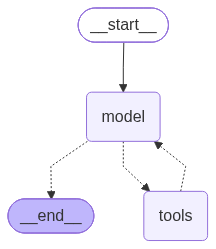

In [10]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

### 限制工具调用次数
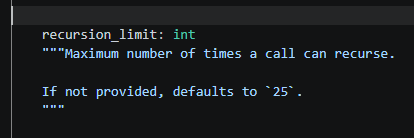


In [ ]:
config = {
    "recursion_limit":3
}
response =  agent.invoke(input,config=config)